# Scikit-learn Pipeline Tutorial
## Supervised Classification with the Iris Dataset

In the previous notebook we used K-Means to *discover* clusters without any labels. This notebook flips to **supervised learning**: we'll train a classifier to predict the iris `species` from the four flower measurements.

We keep the same `Pipeline` + `ColumnTransformer` structure, but swap K-Means for a **Random Forest classifier** and add a proper train/test split and evaluation step.

### What changes vs. the clustering notebook?

| Step | Clustering | Classification |
|------|-----------|----------------|
| Target | None (unsupervised) | `species` column |
| Input features | All columns incl. `species` | All columns **except** `species` |
| Model | `KMeans` | `RandomForestClassifier` |
| Evaluation | Crosstab comparison | Accuracy, classification report, confusion matrix |
| Train/test split | Not needed | Required to measure generalisation |

## 1. Imports

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

## 2. Load and Split the Dataset

For supervised learning we need to separate the **features** (`X`) from the **target** (`y`):

- `X` — the four numeric measurements (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`)
- `y` — the `species` column we want to predict

We then split into **train** (80%) and **test** (20%) sets. The test set is held out completely until final evaluation — the pipeline never sees it during fitting.

`stratify=y` ensures each split contains a proportional mix of all three species, which matters for small datasets like this one.

In [2]:
iris = sns.load_dataset("iris")

X = iris.drop(columns="species")
y = iris["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training samples : 120
Test samples     : 30

Class distribution in training set:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64


## 3. Identify Column Types

After dropping `species`, all remaining columns are numeric, so the `ColumnTransformer` will only have a numeric branch this time. We still set this up programmatically so the pattern generalises to datasets with mixed types.

In [3]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Numeric features:     ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Categorical features: []


## 4. Build the Preprocessing Pipelines

Same structure as before. Even though Iris has no missing values, including `SimpleImputer` is good practice — it makes the pipeline robust to real-world data that might have gaps.

**Why scale for a Random Forest?**  
Strictly speaking, tree-based models are invariant to monotonic feature scaling, so `StandardScaler` doesn't affect Random Forest predictions. We include it here because:
1. It keeps the pipeline generalisable — swapping in a distance-based model (SVM, KNN) later requires no changes.
2. It's a harmless no-op for the forest.

In [4]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Only wire up the categorical branch if there are categorical features
transformers = [("num", numeric_transformer, numeric_features)]

preprocessor = ColumnTransformer(transformers)

## 5. Build the Full Classification Pipeline

We use a **`RandomForestClassifier`** as the final estimator:

- Fits an ensemble of decision trees on random feature/sample subsets.
- Averages their predictions → reduces variance vs. a single tree.
- Provides built-in **feature importance** scores.
- `n_estimators=100` — number of trees in the forest.
- `random_state=42` — ensures reproducibility.

The full pipeline:
```
Raw DataFrame (X)
     │
     ▼
ColumnTransformer
  └── num: impute → scale
     │
     ▼
RandomForestClassifier(n_estimators=100)
     │
     ▼
Predicted species labels
```

In [5]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Fit the Pipeline

We call `pipeline.fit(X_train, y_train)` — note the addition of `y_train` compared to the unsupervised notebook.

Under the hood:
1. `ColumnTransformer.fit_transform(X_train)` — fits the imputer and scaler **only on training data**, then transforms it.
2. `RandomForestClassifier.fit(X_transformed, y_train)` — trains 100 decision trees on the scaled training features.

In [6]:
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully.")

Pipeline fitted successfully.


## 7. Evaluate on the Test Set

We now run the fitted pipeline on the **held-out test set**. The pipeline automatically applies the same preprocessing transformations that were learned on the training set — no manual scaling required.

Key metrics:
- **Accuracy** — fraction of correctly classified samples.
- **Precision** — of all predicted positives, how many were correct?
- **Recall** — of all actual positives, how many did we find?
- **F1-score** — harmonic mean of precision and recall.

In [7]:
y_pred = pipeline.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 8. Confusion Matrix

The confusion matrix shows exactly which species were confused with which. Perfect classification produces a diagonal matrix with zeros everywhere else.

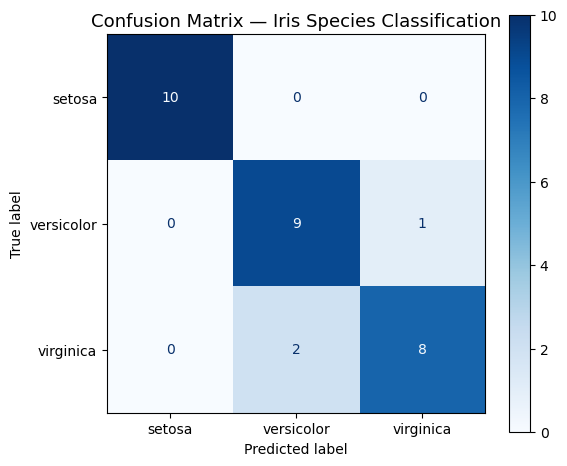

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=pipeline.classes_,
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix — Iris Species Classification", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Cross-Validation

A single 80/20 split can be lucky or unlucky depending on which samples end up in the test set. **k-fold cross-validation** gives a more reliable estimate by:
1. Splitting the data into *k* equal folds.
2. Training on *k−1* folds and evaluating on the remaining fold.
3. Repeating *k* times and averaging the scores.

`cross_val_score` handles this automatically and works natively with pipelines — each fold gets its own independent fit of the entire pipeline.

In [9]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.9667
  Fold 2: 0.9667
  Fold 3: 0.9333
  Fold 4: 0.9667
  Fold 5: 1.0000

  Mean : 0.9667
  Std  : 0.0211


## 10. Feature Importances

Random Forest provides a `feature_importances_` attribute that tells us how much each feature contributed to the model's decisions. Higher values → the feature was used more heavily to split nodes across the forest.

We retrieve the classifier from the pipeline with `pipeline["classifier"]`.

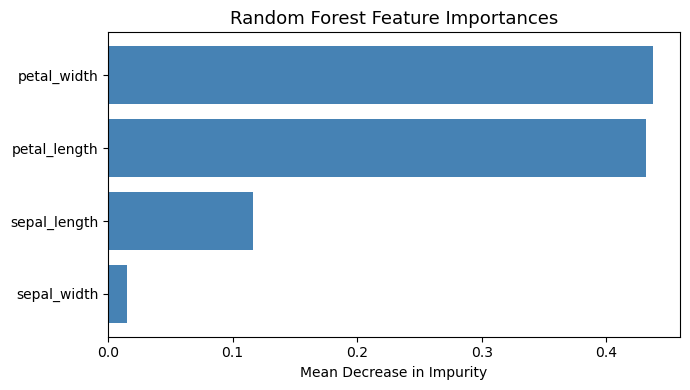

     feature  importance
 petal_width    0.437185
petal_length    0.431466
sepal_length    0.116349
 sepal_width    0.015000


In [10]:
importances = pipeline["classifier"].feature_importances_
feature_names = numeric_features  # after preprocessing, these are the surviving columns

importance_df = pd.DataFrame({
    "feature":   feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

## 11. Predict on New Data

As with the clustering notebook, `pipeline.predict()` handles all preprocessing automatically. Pass in a raw DataFrame with the same column schema as `X_train` and get species predictions back.

In [11]:
new_flowers = pd.DataFrame({
    "sepal_length": [5.1, 6.3, 7.2],
    "sepal_width":  [3.5, 2.8, 3.0],
    "petal_length": [1.4, 4.5, 5.8],
    "petal_width":  [0.2, 1.5, 2.6]
})

predictions   = pipeline.predict(new_flowers)
probabilities = pipeline.predict_proba(new_flowers)

new_flowers["predicted_species"] = predictions
prob_df = pd.DataFrame(probabilities, columns=pipeline.classes_)

result = pd.concat([new_flowers, prob_df], axis=1)
print(result.to_string(index=False))

 sepal_length  sepal_width  petal_length  petal_width predicted_species  setosa  versicolor  virginica
          5.1          3.5           1.4          0.2            setosa     1.0        0.00       0.00
          6.3          2.8           4.5          1.5        versicolor     0.0        0.94       0.06
          7.2          3.0           5.8          2.6         virginica     0.0        0.00       1.00


## Summary

Here's the complete pipeline we built:

```
Pipeline
├── preprocess: ColumnTransformer
│   └── num: Pipeline
│       ├── SimpleImputer(strategy='median')
│       └── StandardScaler()
└── classifier: RandomForestClassifier(n_estimators=100)
```

**Key takeaways vs. the clustering notebook:**

- In supervised learning, `species` moves from a **feature** to the **target** `y`.
- A train/test split is essential — it gives an unbiased estimate of how the model generalises.
- `cross_val_score` works natively with pipelines, fitting each fold independently to avoid leakage.
- `predict_proba()` exposes class probabilities, not just hard labels — useful for confidence thresholds.
- The pipeline is still a single object: fit it once, call `.predict()` anywhere without worrying about preprocessing.